In [1]:
%load_ext autoreload
%autoreload 2
import xarray as xr
import matplotlib.pyplot as plt
from src.loading import *
from src.saving import *

# gSAM Levels vs ERA5 Levels

In [2]:
gsam_eofs = load_gsam_eofs_pcs()
gsam_p = load_gsam_reference_profiles().p.sel(z=gsam_eofs.components().z)
era5_eofs = load_era5_eofs_pcs()
print(f'gSAM ExVar: {gsam_eofs.explained_variance_ratio().sel(mode=[1,2]).sum():0.3f}')
print(f'EOF ExVar: {era5_eofs.explained_variance_ratio().sel(mode=[1,2]).sum():0.3f}')

gSAM ExVar: 0.850
EOF ExVar: 0.773


/var/folders/1t/6drgwyc17q12xmq4h7m454vw0000gn/T/ipykernel_88015/2013988229.py:23: UserWarning: The figure layout has changed to tight
  fig.tight_layout(pad=1)
/var/folders/1t/6drgwyc17q12xmq4h7m454vw0000gn/T/ipykernel_88015/2013988229.py:23: UserWarning: The figure layout has changed to tight
  fig.tight_layout(pad=1)


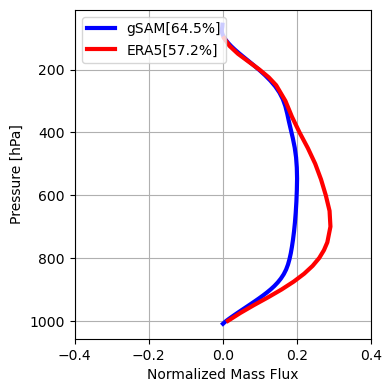

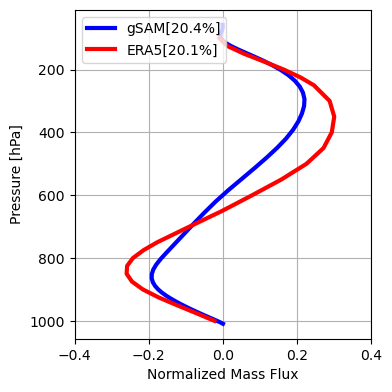

In [3]:

for mode in [1,2]:
    fig, ax = plt.subplots(figsize=(4, 4), constrained_layout=True)
    
    # gSAM Plot
    #
    gsam_profile = gsam_eofs.components().sel(mode=mode)
    gsam_profile = gsam_profile.assign_coords({'p': gsam_p})
    gsam_exp_var = gsam_eofs.explained_variance_ratio().sel(mode=mode)
    gsam_profile.plot(ax=ax, y='p', label=f'gSAM[{100*gsam_exp_var:0.1f}%]', color='blue', lw=3)
    # ERA5 Plot
    #
    era5_profile = era5_eofs.components().sel(mode=mode)
    era5_exp_var = era5_eofs.explained_variance_ratio().sel(mode=mode)
    era5_profile.plot(ax=ax, y='level', label=f'ERA5[{100*era5_exp_var:0.1f}%]', color='red', lw=3)

    ax.invert_yaxis()
    ax.legend(loc='upper left')
    ax.set_xlim(-0.4, 0.4)
    ax.grid()
    ax.set_title(None)
    ax.set_xlabel('Normalized Mass Flux')
    ax.set_ylabel('Pressure [hPa]')
    fig.tight_layout(pad=1)
    save_figure(fig, f'massflux_eof_mode{mode}.pdf')

# gSAM Interpolated onto ERA5 Levels

In [3]:
gsam_eofs = load_gsam_on_era5_levels_eofs_pcs()
era5_eofs = load_era5_eofs_pcs()

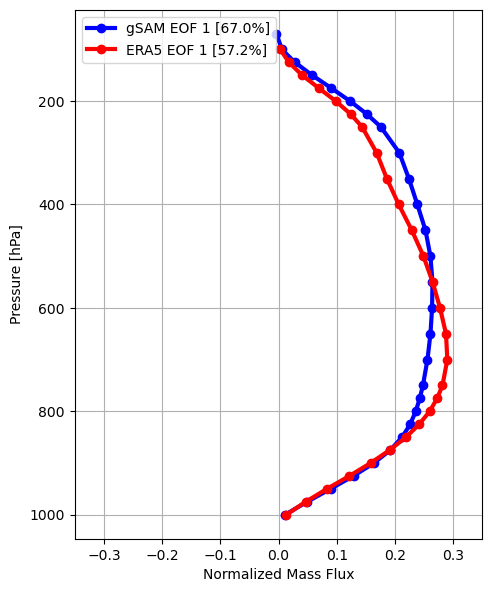

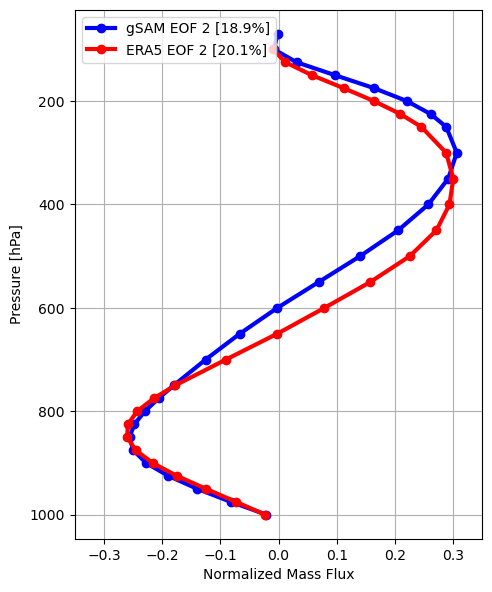

In [5]:
for mode in [1,2]:
    fig, ax = plt.subplots(figsize=(5, 6))
    
    # gSAM Plot
    #
    gsam_profile = gsam_eofs.components().sel(mode=mode)
    gsam_exp_var = gsam_eofs.explained_variance_ratio().sel(mode=mode)
    gsam_profile.plot(ax=ax, y='level', label=f'gSAM EOF {mode} [{100*gsam_exp_var:0.1f}%]', color='blue', marker='o', lw=3)
    # ERA5 Plot
    #
    era5_profile = era5_eofs.components().sel(mode=mode)
    era5_exp_var = era5_eofs.explained_variance_ratio().sel(mode=mode)
    era5_profile.plot(ax=ax, y='level', label=f'ERA5 EOF {mode} [{100*era5_exp_var:0.1f}%]', color='red', marker='o', lw=3)

    ax.invert_yaxis()
    ax.legend(loc='upper left')
    ax.set_xlim(-0.35, 0.35)
    ax.grid()
    ax.set_title(None)
    ax.set_xlabel('Normalized Mass Flux')
    ax.set_ylabel('Pressure [hPa]')
    fig.tight_layout(pad=1)
    # save_figure(fig, f'massflux_eof_era5_levels_mode{mode}.pdf')